# Построение агентной системы на Python

Данная работа посвящена построению агентных систем на LangChain и LangGraph.

Данная работа выполнена студентом ИАД-4 Коноваловым Матвеем и опирается на семинарские ноутбуки.

## В чём разница между LangChain и LangGraph

| Характеристика | LangChain Agents | LangGraph Agents |
|----------------|-----------------|-----------------|
| Кто управляет логикой | Модель (LLM) | Разработчик |
| Гибкость | Ограничена | Абсолютная |
| Сложность | Простые / средние задачи | Сложные воркфлоу |
| Предсказуемость | Низкая | Высокая |
| Память | Минимальная | Любая, структурированная |
| Подходит для продакшена | Иногда | Да |

---

## Вывод

- **LangChain Agents** — быстрый способ собрать помощника: подключаем инструменты, выбираем тип агента, LLM сама решает, что делать.
- **LangGraph Agents** — контроль над каждым шагом: вы строите граф действий, LLM участвует только в отдельных узлах, что делает систему предсказуемой и надёжной.

**Итоговое правило:**
LangChain = “готовые блоки, которые магически вызывают инструменты”
LangGraph = “строим агента сами, LLM помогает на узлах, а логика полностью под нашим контролем”

## Инициализация LLM
LLM это неотъемлемая часть агентных систем, центральный мозг, вызывающий конкретные инструменты или выполняющий работу с текстом, так что без неё мы в этой работе не обойдемся.

Выбор модели проводился на основании [ранкинга LLM в категории Academia на OpenRouter](https://openrouter.ai/rankings?category=academia#categories) (поскольку обе агентных системы связаны с наукой)

In [24]:
!pip install -qU langchain==0.3.25 langchain-openai==0.3.22 langchain-experimental==0.3.4 numexpr==2.11.0


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [25]:
from langchain_openai import ChatOpenAI
from constants import OPENROUTER_API_KEY

llm = ChatOpenAI(
    model="stepfun/step-3.5-flash:free",
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
    temperature=0,
)

## ReAct-агент на LangChain

Я часто провожу эксперименты в Jupyter и записываю конспекты результатов в Obsidian, попробуем это автоматизировать.

Очевидно, всё, что ему надо уметь, это читать .md и .ipynb, записывать и перезаписывать в .md.

In [26]:
from pathlib import Path
from datetime import datetime
import json
import nbformat

from langchain.memory import ConversationBufferMemory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.base import RunnableSerializable
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool

### Константы
Агент бы мог получать пути из разговора, но я не доверяю ему доступ к записи в рандомные файлы в своём Obsidian.

In [27]:
# Jupyter notebook, из которого агент читает эксперимент
FIXED_NOTEBOOK_PATH = Path("Коновалов_LC_LG.ipynb").resolve()

# Конкретная заметка в Obsidian, куда агент имеет право писать
FIXED_OBSIDIAN_NOTE_PATH = Path("./test.md").resolve()

print("Notebook:", FIXED_NOTEBOOK_PATH)
print("Obsidian note:", FIXED_OBSIDIAN_NOTE_PATH)

Notebook: /Users/ashentide/PycharmProjects/IAD/AppliedDataAnalysisProblems/1/agents.ipynb
Obsidian note: /Users/ashentide/PycharmProjects/IAD/AppliedDataAnalysisProblems/1/test.md


### Вспомогательные функции

In [28]:
def _serialize_output(output) -> str:
    if output is None:
        return ""

    if isinstance(output, str):
        return output.strip()

    if isinstance(output, (int, float, bool)):
        return str(output)

    if isinstance(output, dict):
        if "text" in output:
            text = output.get("text")
            if isinstance(text, list):
                return "\n".join(str(x) for x in text).strip()
            return str(text).strip()

        if output.get("output_type") == "stream":
            text = output.get("text", "")
            if isinstance(text, list):
                return "\n".join(str(x) for x in text).strip()
            return str(text).strip()

        if output.get("output_type") in {"execute_result", "display_data"}:
            data = output.get("data", {})
            if "text/plain" in data:
                plain = data["text/plain"]
                if isinstance(plain, list):
                    return "\n".join(str(x) for x in plain).strip()
                return str(plain).strip()

        return json.dumps(output, ensure_ascii=False, indent=2)

    return str(output).strip()

### Инструменты
Очень удобно, что у любого инструмента есть подпись по дизайну библиотеки.

In [29]:
@tool
def read_fixed_jupyter_notebook(max_cells: int = 96) -> str:
    """Прочитать заранее заданный Jupyter notebook и вернуть последние содержательные ячейки с кодом, markdown и текстовыми outputs."""
    path = FIXED_NOTEBOOK_PATH
    if not path.exists():
        return f"Notebook не найден: {path}"

    nb = nbformat.read(path, as_version=4)
    meaningful_cells = [cell for cell in nb.cells if cell.get("source", "").strip()]

    if not meaningful_cells:
        return "В notebook нет содержательных ячеек."

    chunks = []
    selected_cells = meaningful_cells[-max_cells:]

    for idx, cell in enumerate(selected_cells, start=1):
        cell_type = cell.get("cell_type", "unknown")
        source = cell.get("source", "").strip()

        block = [f"[{idx}] type={cell_type}"]

        if cell_type == "markdown":
            block.append(source)

        elif cell_type == "code":
            block.append("CODE:")
            block.append(source)

            outputs = cell.get("outputs", [])
            rendered_outputs = []

            for out in outputs[:3]:
                rendered = _serialize_output(out)
                if rendered:
                    rendered_outputs.append(rendered)

            if rendered_outputs:
                block.append("OUTPUT:")
                block.append("\n---\n".join(rendered_outputs))

        else:
            block.append(source)

        chunks.append("\n".join(block))

    return "\n\n".join(chunks)

In [30]:
@tool
def read_fixed_obsidian_note() -> str:
    """Прочитать заранее заданную markdown-заметку Obsidian."""
    path = FIXED_OBSIDIAN_NOTE_PATH
    if not path.exists():
        return f"Заметка пока не существует: {path}"
    return path.read_text(encoding="utf-8")

In [31]:
@tool
def write_fixed_obsidian_note(content: str) -> str:
    """Перезаписать заранее заданную markdown-заметку Obsidian."""
    path = FIXED_OBSIDIAN_NOTE_PATH
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding="utf-8")
    return f"Заметка сохранена: {path}"

In [32]:
@tool
def append_fixed_obsidian_note(content: str) -> str:
    """Дописать текст в конец заранее заданной markdown-заметки Obsidian."""
    path = FIXED_OBSIDIAN_NOTE_PATH
    path.parent.mkdir(parents=True, exist_ok=True)

    prefix = ""
    if path.exists():
        existing = path.read_text(encoding="utf-8")
        if existing.strip():
            prefix = "\n\n"

    with path.open("a", encoding="utf-8") as f:
        f.write(prefix + content)

    return f"Заметка дополнена: {path}"

In [33]:
@tool
def final_answer(answer: str, tools_used: list[str]) -> dict:
    """Используй этот инструмент, чтобы вернуть финальный ответ пользователю."""
    return {"answer": answer, "tools_used": tools_used}

In [34]:
obsidian_tools = [
    read_fixed_jupyter_notebook,
    read_fixed_obsidian_note,
    write_fixed_obsidian_note,
    append_fixed_obsidian_note,
    final_answer,
]

name2tool = {tool.name: tool.func for tool in obsidian_tools}

### Мозг агента

In [35]:
obsidian_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "Ты агент-ассистент исследователя. "
        "Твоя задача — читать фиксированный Jupyter notebook и фиксированную заметку Obsidian, "
        "после чего собирать короткий и практичный markdown-конспект эксперимента. "
        "У тебя нет доступа к произвольным путям: все инструменты уже работают только с заранее заданными файлами. "
        "Если заметка уже существует, можешь прочитать её и решить, лучше перезаписать её целиком или дополнить. "
        "Итоговую заметку оформляй в markdown со структурой:\n"
        "# Заголовок\n\n"
        "## Контекст\n"
        "## Проверяемые гипотезы\n"
        "## Эксперименты\n"
        "## Результаты\n"
        "Конспект должен быть коротким, точным и полезным. "
        "Финальный ответ пользователю всегда заверши через инструмент final_answer."
    ),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

In [36]:
obsidian_agent: RunnableSerializable = obsidian_prompt | llm.bind_tools(
    obsidian_tools,
    tool_choice="auto",
)

In [37]:
class ObsidianExperimentAgent:
    def __init__(self, max_iterations: int = 6):
        self.max_iterations = max_iterations
        self.agent = obsidian_agent
        self.memory = ConversationBufferMemory(
            memory_key="chat_history",
            return_messages=True,
        )

    def invoke(self, user_input: str) -> dict:
        chat_history = self.memory.load_memory_variables({}).get("chat_history", [])
        agent_scratchpad = []
        final_text = ""

        for _ in range(self.max_iterations):
            response = self.agent.invoke({
                "input": user_input,
                "chat_history": chat_history,
                "agent_scratchpad": agent_scratchpad,
            })

            agent_scratchpad.append(response)

            if not response.tool_calls:
                final_text = response.content
                break

            stop = False

            for tool_call in response.tool_calls:
                tool_name = tool_call["name"]
                tool_args = tool_call["args"]
                tool_call_id = tool_call["id"]

                tool_out = name2tool[tool_name](**tool_args)

                agent_scratchpad.append(
                    ToolMessage(
                        content=f"{tool_out}",
                        tool_call_id=tool_call_id,
                    )
                )

                print(f"{tool_name}({tool_args}) -> {tool_out}")

                if tool_name == "final_answer":
                    final_text = tool_args["answer"]
                    stop = True
                    break

            if stop:
                break

        self.memory.save_context({"input": user_input}, {"output": final_text})
        return {"output": final_text}

In [38]:
obsidian_experiment_agent = ObsidianExperimentAgent()

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_48342/4151532600.py:5: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  self.memory = ConversationBufferMemory(


### Пример использования агента

In [ ]:
result = obsidian_experiment_agent.invoke("Собери полное саммари ноутбука")
print(result["output"])

In [40]:
from IPython.display import display, Markdown
Markdown(filename='test.md')

# Построение агентной системы на Python: LangChain vs LangGraph

## Контекст
Работа посвящена построению агентных систем на LangChain и LangGraph для автоматизации исследовательских задач. Студент ИАД-4 Матвей Коновалов реализовал и сравнил два подхода:

- **LangChain Agents** — быстрый способ собрать помощника с автоматическим выбором инструментов LLM
- **LangGraph Agents** — полный контроль над логикой через построение графа состояний

Основной фокус — создание агента на LangGraph, который автоматически анализирует исследовательский код, ищет релевантные научные статьи через arXiv API и оценивает научную новизну реализованного подхода.

## Проверяемые гипотезы
1. LangGraph обеспечивает большую предсказуемость и контроль над сложными воркфлоу по сравнению с LangChain
2. Возможно автоматизировать процесс поиска и анализа научных статей по заданному коду
3. Агент способен точно извлекать алгоритмическую структуру из кода и строить эффективные поисковые запросы
4. Система может надёжно определять, является ли реализованный алгоритм новым или уже покрыт существующей литературой

## Эксперименты

### Инициализация LLM
Выбрана модель `stepfun/step-3.5-flash:free` через OpenRouter API на основе ранкинга LLM в категории Academia.

### ReAct-агент на LangChain
Реализован простой агент с инструментами для работы с фиксированными файлами:
- `read_fixed_jupyter_notebook()` — чтение ноутбука
- `read_fixed_obsidian_note()` — чтение заметки Obsidian
- `write_fixed_obsidian_note()` — перезапись заметки
- `append_fixed_obsidian_note()` — дополнение заметки
- `final_answer()` — возврат финального ответа

Агент умеет собирать конспект эксперимента по заданной структуре.

### Агент на LangGraph для анализа научной новизны
Построен сложный граф состояний с этапами:

1. **summarize_code** — LLM извлекает общие сигналы из кода (задача, тип метода, ключевые термины, концепты, поисковые подсказки)
2. **extract_algorithmic_structure** — извлечение строгой алгоритмической структуры: исследовательский вопрос, тип алгоритма, сигнатура шагов, используемые методы, технические детали, ключевые фрагменты кода
3. **build_queries** — построение множества поисковых запросов к arXiv (title anchors, mechanism queries, broad grounded queries, soft OR queries)
4. **get_papers** — выполнение поиска по arXiv API и сбор уникальных статей
5. **filter_papers_by_relevance** — первичная фильтрация статей через LLM по релевантности механизму кода
6. **extract_paper_algorithms** — детальное извлечение алгоритмов из статей:
   - Попытка парсинга TeX/PDF для поиска блоков `algorithm`, `algorithmic`, `procedure`
   - Выбор раздела метода по заголовкам
   - Fallback на LLM-извлечение из текста статьи
   - Кэширование результатов в SQLite
7. **match_code_to_papers** — сопоставление алгоритмов:
   - Ранжирование статей для глубокого сопоставления
   - Пошаговое сравнение структуры кода и статей с определением уровня совпадения (one_to_one, partial, background)
8. **summarize_papers** — финальное саммари с разделением на три уровня релевантности и вывод о научной новизне

### Тестирование
Передан пример кода, реализующего оценку проводимости (conductance) нейронов с использованием:
- Path integration вдоль пути от baseline к входу
- Hook на промежуточный слой
- Градиент скора класса по активациям (`∂F/∂y`)
- Jacobian-vector product (JVP) для `dy/dα`
- Конечная разность как fallback

Код основан на идеях из статей:
- "Improving Adversarial Transferability via Neuron Attribution-Based Attacks"
- "How important is a neuron?"

## Результаты

### Сравнение LangChain и LangGraph
| Характеристика | LangChain Agents | LangGraph Agents |
|----------------|-----------------|-----------------|
| Кто управляет логикой | Модель (LLM) | Разработчик |
| Гибкость | Ограничена | Абсолютная |
| Сложность | Простые/средние задачи | Сложные воркфлоу |
| Предсказуемость | Низкая | Высокая |
| Память | Минимальная | Любая, структурированная |
| Подходит для продакшена | Иногда | Да |

**Вывод:** LangChain подходит для быстрых прототипов, LangGraph — для сложных, предсказуемых систем.

### Результаты работы агента на LangGraph
Агент нашёл несколько статей, но **ни одна не описывает алгоритм почти один в один** с реализованным кодом.

#### 1. Статьи, где это уже есть почти один в один
**Нет таких статей.** Алгоритмическая сигнатура кода (интегрирование вдоль пути, hook на слой, `∂F/∂y`, JVP, накопление `grad_y * act_tangent`) не встречается в явном виде.

#### 2. Частично релевантные статьи
- **SPINRec** — path integration для объяснений, но использует усреднение по множеству baseline, а не численное интегрирование с градиентами по активациям
- **CrossEAI** — градиентные методы объяснений (Guided Backpropagation, Grad-CAM++), но нет path integration и JVP
- **Plan2Vec** — path integration для дискретных графов состояний, а не непрерывное интегрирование вдоль пути между входами
- **Space2Vec** — вдохновение grid cells для пространственных представлений, но другой алгоритм

#### 3. Фоновые, но полезные статьи
- **Boosting Brain-inspired Path Integration Efficiency** — path integration в навигации
- **Adaptive Path-Integral Autoencoder** — path integral для обучения представлений и планирования
- **A minimalistic representation model for head direction system** — constrained learning в нейробиологических моделях
- **How Much Off-The-Shelf Knowledge Is Transferable** — оценка переносимости знаний по слоям
- **On Path Integration of Grid Cells** — теоретический анализ path integration
- **Agglomerative clustering via exponent generating function** — path integral descriptor для кластеризации

#### 4. Что в коде выглядит потенциально новым
Ключевые **новые/неочевидные элементы**:

1. **Гибрид neuron conductance с path integration и JVP:**
   - Оценка вклада промежуточных активаций конкретного слоя/нейрона через численное интегрирование вдоль пути от baseline к входу
   - Использование `∂F/∂y` (градиент скора класса по активации слоя) вместо `∂F/∂x`
   - Умножение на `dy/dα`, вычисленное через JVP или конечную разность
   - Накопление `grad_y * act_tangent`

2. **Техническая реализация:**
   - Hook для извлечения активаций промежуточного слоя в процессе интегрирования
   - Fallback на конечную разность при ошибке JVP
   - Очистка кэша бэкенда и хуков после каждого шага

3. **Цель:** оценка вклада активаций слоя в изменение предсказания при переходе от baseline к входу — задача, не решаемая описанным способом в найденных статьях.

**Итоговый вывод:** Алгоритм представляет собой **специализированный метод интерпретируемости**, который интегрирует несколько идей (conductance, path integration, JVP) в новую комбинацию. Он не дублирует ни один из найденных алгоритмов, хотя использует общие концепции. Таким образом, в коде присутствует **научная новизна**.

### Проблемы и ограничения
- **Построение запросов к arXiv** — LLM не всегда эффективно формирует query для API, требуется доработка (возможен переход на Semantic Scholar или OpenAlex)
- **Детерминированность** — из-за использования LLM для многих шагов результаты могут варьироваться
- **Скорость** — извлечение алгоритмов из TeX/PDF и LLM-обработка занимают время
- **Кэширование** — реализовано, но требует очистки при изменениях

### Практическая ценность
Агент автоматизирует рутинную задачу поиска и анализа научных статей, помогая исследователю быстро оценить, является ли его работа новой. Система демонстрирует возможности LangGraph для построения сложных, контролируемых AI-воркфлоу.

## Агент на LangGraph
Агент должен обращаться по API, обрабатывать ответ LLM-кой и выдавать в ответе, причем должна решаться полезная для меня задача.

В ходе написания кода для исследований меня часто посещает вопрос "а точно ли то, чем я сейчас занимаюсь, не рассматривалось кем-то в статье?".

Поэтому мой агент будет читать мой код, искать релевантные статьи через API arXiv и саммаризировать для меня, какие вопросы полностью затрагивались, что упоминалось частично, а что представляет научную новизну.

В будущем планируется отвязать агента от кода, чтобы была опция просто у него спрашивать, какие статьи на интересующую меня тему существуют. Чистая LLM-ка, что

In [3]:
!pip install -q langgraph==0.2.76 arxiv charset_normalizer


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
from typing import TypedDict, List, Dict, Any, Optional, Tuple
import json
import textwrap
import arxiv
from langgraph.graph import START, END, StateGraph
import os
import re
import io
import tarfile
import posixpath
import sqlite3
import hashlib
import requests
import fitz  # PyMuPDF
from datetime import datetime

In [5]:
class AgentState(TypedDict, total=False):
    code: str
    code_summary: str
    extracted_signals: Dict[str, Any]
    algorithmic_structure: Dict[str, Any]
    queries: List[str]
    papers: List[Dict[str, str]]
    paper_algorithms: List[Dict[str, Any]]
    paper_matches: List[Dict[str, Any]]
    final_summary: str

In [6]:
VERBOSE = False
TOP_PAPERS_FOR_RELEVANCE_FILTER = 10
TOP_PAPERS_FOR_LLM_ALGO_EXTRACTION = 3
TOP_PAPERS_FOR_MATCHING = 10
TOP_PAPERS_FOR_DEEP_MATCHING = 6
ALGO_MATCH_SCORE_THRESHOLD = 0.45
ALGORITHM_DB_PATH = os.path.abspath("paper_algorithms_cache.sqlite3")

### Шаг 1. Извлечение сигналов из кода

Здесь LLM-ка, подобно backbone, извлекающему признаки с картинки, извлекает сигналы из кода, по которым дальше будет происходить поиск релевантных статей.

In [7]:
def clean_llm_json_text(text: str) -> str:
    cleaned = (text or "").strip()
    if cleaned.startswith("```json"):
        cleaned = cleaned[len("```json"):].strip()
    if cleaned.startswith("```"):
        cleaned = cleaned[len("```"):].strip()
    if cleaned.endswith("```"):
        cleaned = cleaned[:-3].strip()
    return cleaned


def parse_llm_json(text: str, fallback: Dict[str, Any]) -> Dict[str, Any]:
    cleaned = clean_llm_json_text(text)
    try:
        return json.loads(cleaned)
    except Exception:
        return fallback

In [8]:
def summarize_code(state: AgentState):
    prompt = f"""
Ты анализируешь код исследовательского проекта и готовишь его описание для поиска научных статей.

Нужно вернуть JSON-объект со следующими полями:
- task: краткое название задачи;
- method_kind: тип метода или эксперимента;
- keywords: список ключевых терминов из кода;
- concepts: список более общих исследовательских концептов;
- method_markers: список используемых технических методов и механизмов;
- search_hints: 3-6 коротких поисковых фраз для arXiv.

Вот несколько примеров method_markers (они не обязательно представлены и ты можешь использовать пример не из списка):
- важность через градиент выхода по промежуточному слою;
- feature-level objective;
- интегрирование по пути от baseline к входу;
- итеративная атака с проекцией в L_inf-шар;
- momentum update;
- hook на промежуточный слой;
- сравнение важных и атакованных фич;
- корреляционный или иной анализ связи важности и атаки.

Ответ верни строго в формате JSON без пояснений.

Код:
{state['code']}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("summarize_code raw result:\n", result)

    extracted_signals = parse_llm_json(
        result,
        {
            "task": "unknown",
            "method_kind": "unknown",
            "keywords": [],
            "concepts": [],
            "method_markers": [],
            "search_hints": []
        },
    )

    code_summary = textwrap.dedent(
        f"""
        Task: {extracted_signals.get('task', 'unknown')}
        Method kind: {extracted_signals.get('method_kind', 'unknown')}
        Keywords: {', '.join(extracted_signals.get('keywords', []))}
        Concepts: {', '.join(extracted_signals.get('concepts', []))}
        Method markers: {', '.join(extracted_signals.get('method_markers', []))}
        """
    ).strip()

    if VERBOSE:
        print("Parsed extracted_signals:", extracted_signals)

    return {
        "extracted_signals": extracted_signals,
        "code_summary": code_summary,
    }

### Шаг 2. Извлечение алгоритмической структуры и исследовательского вопроса

Одних общих сигналов недостаточно: для точного поиска статей нужно отдельно извлечь алгоритмический скелет кода. На этом шаге LLM формирует более строгую структуру: основной алгоритм, исследовательский вопрос, используемые методы, характерные шаги процедуры и ключевые фрагменты кода, которые потом пойдут в финальное сопоставление со статьями.

In [9]:
def extract_algorithmic_structure(state: AgentState):
    prompt = f"""
Ты анализируешь код исследовательского проекта. Тебе нужно извлечь не общую тему, а алгоритмическую структуру и исследовательский вопрос.

Верни строго JSON-объект со следующими полями:
- research_question: главный исследовательский вопрос или проверяемая гипотеза;
- algorithm_type: краткий тип алгоритма;
- algorithm_signature: список из 4-8 коротких шагов, описывающих основную процедуру;
- methods_used: список используемых методов и механизмов;
- implementation_markers: список важных технических деталей реализации;
- key_code_spans: список из 3-6 коротких фрагментов кода или псевдокода, которые лучше всего описывают основной алгоритм.

Важно:
- methods_used должен явно выделять используемые методы, например: gradient of class score w.r.t. intermediate features, path integration, feature attribution, feature-level attack objective, momentum iterative update, Linf projection, hook-based feature extraction, comparison of important vs attacked features, attribution/perturbation alignment analysis;
- algorithm_signature должен описывать именно ход алгоритма, а не просто перечислять ключевые слова;
- key_code_spans должны быть короткими, но содержательными и буквально опираться на код.

Ответ верни строго в формате JSON без пояснений.

Код:
{state['code']}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("extract_algorithmic_structure raw result:\n", result)

    algorithmic_structure = parse_llm_json(
        result,
        {
            "research_question": "unknown",
            "algorithm_type": "unknown",
            "algorithm_signature": [],
            "methods_used": [],
            "implementation_markers": [],
            "key_code_spans": []
        }
    )

    if VERBOSE:
        print("Parsed algorithmic_structure:", algorithmic_structure)

    return {"algorithmic_structure": algorithmic_structure}

### Шаг 3. Построение нескольких поисковых запросов

Чтобы повысить полноту поиска, агент строит не один запрос, а несколько: более буквальные и более концептуальные. Задача - накидать побольше статей и уже потом среди них выделить самые релевантные, ибо важно не пропустить ни одной статьи, которая повторяет подходы из кода.

Эксперименты показали, что у ллмки не получается эффективно формировать query для arxiv API, так что в будущем планируется переезд на API Semantic Scholar (правда в России API-ключ должно быть трудно получить) или OpenAlex (вот это уже более реально).

In [10]:
def build_queries(state: AgentState):
    code_summary = state["code_summary"]
    extracted_signals = state["extracted_signals"]
    algorithmic_structure = state["algorithmic_structure"]

    prompt = f"""
У тебя есть описание кода, извлечённые семантические сигналы и алгоритмическая структура.
Нужно извлечь из них хорошие ЛИТЕРАТУРНЫЕ ТЕРМИНЫ для поиска статей в arXiv.

Важно:
- arXiv не является semantic search;
- термины должны быть похожи на слова и фразы из title/abstract реальных научных статей;
- не нужно генерировать сразу готовые arXiv-запросы;
- не нужно переобучаться на низкоуровневые детали реализации;
- не нужно подгонять результат под одну конкретную статью.

Нужно вернуть строго JSON-объект такого вида:
{{
  "canonical_terms": [...],
  "synonym_terms": [...],
  "title_like_phrases": [...],
  "avoid_terms": [...]
}}

Где:
- canonical_terms: 6-10 наиболее правдоподобных литературных терминов или коротких терминологических фраз;
- synonym_terms: 6-10 близких формулировок, которыми авторы могли бы описывать тот же механизм;
- title_like_phrases: 4-8 коротких естественных фраз, похожих на реальные фрагменты названий статей;
- avoid_terms: 6-12 слов или фраз, которые выглядят как implementation-specific шум, плохие якоря для поиска или термины из нерелевантных областей.

Правила:
- canonical_terms и synonym_terms должны быть короткими и правдоподобными для литературы;
- title_like_phrases должны звучать естественно;
- avoid_terms должны включать низкоуровневые детали реализации, если они не выглядят как устойчивые литературные термины;
- не использовать слишком общие слова без механистического уточнения;
- не использовать формулировки, похожие на строку кода или комментарий к коду.

Описание кода:
{code_summary}

Извлечённые сигналы:
{json.dumps(extracted_signals, ensure_ascii=False, indent=2)}

Алгоритмическая структура:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("build_queries raw term extraction result:\n", result)

    parsed = parse_llm_json(
        result,
        {
            "canonical_terms": [],
            "synonym_terms": [],
            "title_like_phrases": [],
            "avoid_terms": [],
        },
    )

    def dedupe_keep_order(items):
        seen = set()
        out = []
        for item in items:
            key = item.lower()
            if key not in seen:
                seen.add(key)
                out.append(item)
        return out

    def sanitize_phrase(value: str) -> str:
        value = re.sub(r"\s+", " ", str(value)).strip()
        value = value.strip("\"'")
        return value

    canonical_terms = [
        sanitize_phrase(x)
        for x in parsed.get("canonical_terms", [])
        if sanitize_phrase(x)
    ]
    synonym_terms = [
        sanitize_phrase(x)
        for x in parsed.get("synonym_terms", [])
        if sanitize_phrase(x)
    ]
    title_like_phrases = [
        sanitize_phrase(x)
        for x in parsed.get("title_like_phrases", [])
        if sanitize_phrase(x)
    ]
    avoid_terms = [
        sanitize_phrase(x).lower()
        for x in parsed.get("avoid_terms", [])
        if sanitize_phrase(x)
    ]

    canonical_terms = dedupe_keep_order(canonical_terms)
    synonym_terms = dedupe_keep_order(synonym_terms)
    title_like_phrases = dedupe_keep_order(title_like_phrases)
    avoid_terms = dedupe_keep_order(avoid_terms)

    if VERBOSE:
        print("Canonical terms:", canonical_terms)
        print("Synonym terms:", synonym_terms)
        print("Title-like phrases:", title_like_phrases)
        print("Avoid terms:", avoid_terms)

    category_clause = "(cat:cs.LG OR cat:cs.AI OR cat:cs.CV OR cat:stat.ML)"

    def make_abs_or_clause(terms: List[str], max_terms: int = 3) -> str:
        cleaned = []
        seen = set()
        for term in terms:
            t = sanitize_phrase(term)
            if not t:
                continue
            key = t.lower()
            if key in seen:
                continue
            seen.add(key)
            cleaned.append(t)
            if len(cleaned) >= max_terms:
                break

        if not cleaned:
            return ""
        if len(cleaned) == 1:
            return f'abs:"{cleaned[0]}"'
        return "(" + " OR ".join(f'abs:"{term}"' for term in cleaned) + ")"

    def add_query(queries: List[str], query: str):
        q = re.sub(r"\s+", " ", query).strip()
        if q:
            queries.append(q)

    queries: List[str] = []

    # Bucket 1: title anchors.
    for phrase in title_like_phrases[:4]:
        add_query(queries, f'ti:"{phrase}" AND {category_clause}')

    # Bucket 2: medium-strength mechanism queries.
    primary = canonical_terms[:3]
    secondary = synonym_terms[:3]
    tertiary = canonical_terms[3:6] + synonym_terms[3:6]

    primary_clause = make_abs_or_clause(primary, max_terms=3)
    secondary_clause = make_abs_or_clause(secondary, max_terms=3)
    tertiary_clause = make_abs_or_clause(tertiary, max_terms=3)

    if primary_clause and secondary_clause:
        add_query(queries, f"{primary_clause} AND {secondary_clause} AND {category_clause}")
    if primary_clause and tertiary_clause:
        add_query(queries, f"{primary_clause} AND {tertiary_clause} AND {category_clause}")
    if secondary_clause and tertiary_clause:
        add_query(queries, f"{secondary_clause} AND {tertiary_clause} AND {category_clause}")

    # Bucket 3: broader grounded queries for recall.
    domain_anchors = [
        "neural networks",
        "deep learning",
        "representation learning",
        "adversarial attack",
        "interpretability",
        "feature attribution",
    ]

    broad_terms = dedupe_keep_order(canonical_terms[:4] + synonym_terms[:4])
    for idx, term in enumerate(broad_terms[:4]):
        domain = domain_anchors[idx % len(domain_anchors)]
        add_query(queries, f'abs:"{term}" AND abs:"{domain}" AND {category_clause}')

    # Bucket 4: soft OR queries.
    soft_pool = dedupe_keep_order(canonical_terms[:4] + synonym_terms[:4])
    if len(soft_pool) >= 2:
        soft_clause = make_abs_or_clause(soft_pool, max_terms=4)
        add_query(queries, f"{soft_clause} AND {category_clause}")

    # Bucket 5: mixed title/abstract queries.
    for phrase, term in zip(title_like_phrases[:2], canonical_terms[:2]):
        add_query(queries, f'ti:"{phrase}" OR (abs:"{term}" AND {category_clause})')

    banned_substrings = [
        "research question",
        "algorithm signature",
        "implementation markers",
        "key code spans",
        "line of code",
        "source code",
        "cache clearing",
        "quantum",
        "einstein",
        "hamiltonian",
        "finite difference fallback",
        "jacobian-vector product",
        "hook-based",
    ]

    cleaned_queries = []
    seen_queries = set()
    for query in queries:
        q = re.sub(r"\s+", " ", query).strip()
        q_lower = q.lower()

        if not q:
            continue
        if any(bad in q_lower for bad in banned_substrings):
            continue
        if any(bad and bad in q_lower for bad in avoid_terms):
            continue
        if q_lower in seen_queries:
            continue

        seen_queries.add(q_lower)
        cleaned_queries.append(q)

    cleaned_queries = cleaned_queries[:15]

    if VERBOSE:
        print("Queries:", cleaned_queries)

    return {"queries": cleaned_queries}

### Шаг 4. Поиск статей через arXiv API

Наконец этап без LLM, но с обращением по API. Для каждого запроса берём несколько результатов, после чего объединяем их и убираем дубликаты по названию статьи.

In [11]:
def get_papers(state: AgentState):
    queries = state.get("queries", [])
    all_papers = []
    seen_titles = set()
    seen_urls = set()

    for query in queries:
        if VERBOSE:
            print(f"Searching arXiv for query: {query}")

        try:
            search = arxiv.Search(
                query=query,
                max_results=12,
                sort_by=arxiv.SortCriterion.Relevance,
            )

            for result in search.results():
                title = (result.title or "").strip()
                summary = (result.summary or "").strip()
                url = (result.entry_id or "").strip()
                published = str(result.published.date()) if result.published else ""

                norm_title = re.sub(r"\s+", " ", title.lower()).strip()

                if not title or not url:
                    continue
                if norm_title in seen_titles or url in seen_urls:
                    continue

                seen_titles.add(norm_title)
                seen_urls.add(url)

                all_papers.append(
                    {
                        "title": title,
                        "summary": summary,
                        "published": published,
                        "url": url,
                        "query": query,
                    }
                )
        except Exception as e:
            if VERBOSE:
                print(f"arXiv search failed for query '{query}': {e}")

    if VERBOSE:
        print(f"Total unique papers found: {len(all_papers)}")
        print("ALL RETRIEVED PAPERS:")
        for i, paper in enumerate(all_papers, 1):
            print(i, paper["title"])

    return {"papers": all_papers}

### Шаг 5. Первичная фильтрация найденных статей

После поиска по arXiv агент сначала делает дешёвую фильтрацию найденных статей по title и summary. Цель этого шага — убрать заведомо нерелевантные статьи до тяжёлого этапа извлечения алгоритмов из TeX/PDF.

In [12]:
def filter_papers_by_relevance(state: AgentState):
    papers = state.get("papers", [])
    algorithmic_structure = state.get("algorithmic_structure", {})
    code_summary = state.get("code_summary", "")

    if not papers:
        return {"papers": []}

    compact_papers = []
    for idx, paper in enumerate(papers, start=1):
        compact_papers.append(
            {
                "index": idx,
                "title": paper.get("title", ""),
                "summary": paper.get("summary", ""),
                "published": paper.get("published", ""),
                "query": paper.get("query", ""),
                "url": paper.get("url", ""),
            }
        )

    prompt = f"""
У тебя есть описание кода, его алгоритмическая структура и список найденных статей. Нужно оставить только статьи, которые реально похожи на код по механизму, а не просто по общим словам.

Верни строго JSON-массив объектов со следующими полями:
- index: номер статьи из входного списка;
- relevance_score: число от 0 до 1;
- keep: true или false;
- short_reason: очень короткая причина на русском.

Правила отбора:
- ориентируйся прежде всего на algorithm_type, algorithm_signature и methods_used;
- повышай статьи, где видны близкие механистические термины, даже если названия не совпадают буквально;
- учитывай близкие литературные синонимы, а не только точные слова из кода;
- не требуй редких implementation-specific слов для высокой оценки;
- не завышай статьи, совпадающие только по очень общим словам вроде neural network, feature, gradient, importance;
- сильно понижай статьи из явно чужих областей: finite fields, cloud systems, speech/audio, mechanical systems, medicine, document processing, pure mathematics, generic optimization без явной связи с механизмом кода.

Описание кода:
{code_summary}

Алгоритмическая структура кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Найденные статьи:
{json.dumps(compact_papers, ensure_ascii=False, indent=2)}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("filter_papers_by_relevance raw result:\n", result)

    cleaned = clean_llm_json_text(result)
    try:
        ranked = json.loads(cleaned)
    except Exception:
        ranked = []

    ranked_by_index = {
        item.get("index"): item
        for item in ranked
        if isinstance(item, dict) and isinstance(item.get("index"), int)
    }

    enriched = []
    for idx, paper in enumerate(papers, start=1):
        meta = ranked_by_index.get(idx, {})
        enriched_paper = dict(paper)
        enriched_paper["relevance_score"] = float(meta.get("relevance_score", 0.0) or 0.0)
        enriched_paper["keep"] = bool(meta.get("keep", False))
        enriched_paper["short_reason"] = meta.get("short_reason", "")
        enriched.append(enriched_paper)

    enriched.sort(key=lambda x: x.get("relevance_score", 0.0), reverse=True)
    filtered = [paper for paper in enriched if paper.get("keep", False)]
    if len(filtered) < TOP_PAPERS_FOR_RELEVANCE_FILTER:
        filtered = enriched[:TOP_PAPERS_FOR_RELEVANCE_FILTER]
    else:
        filtered = filtered[:TOP_PAPERS_FOR_RELEVANCE_FILTER]

    if VERBOSE:
        print("RELEVANCE FILTER INPUT:")
        for i, p in enumerate(papers, 1):
            print(i, p["title"])

        print("RELEVANCE FILTER SCORES:")
        for paper in enriched:
            print(
                f"{paper.get('relevance_score', 0.0):.2f} | keep={paper.get('keep', False)} | "
                f"{paper.get('title', '')} | {paper.get('short_reason', '')}"
            )

        print(f"Filtered papers count: {len(filtered)} out of {len(papers)}")
        for paper in filtered:
            print(
                f"  score={paper.get('relevance_score', 0.0):.2f} | "
                f"title={paper.get('title', '')} | "
                f"reason={paper.get('short_reason', '')}"
            )

    return {"papers": filtered}

### Шаг 6. Извлечение алгоритмов из найденных статей

Теперь агент сначала пытается извлечь алгоритм детерминированно — из TeX или PDF. Если это удаётся, результат сразу сохраняется в БД и потом переиспользуется. Если явного алгоритма нет, агент берёт релевантный кусок статьи или весь её текст и просит LLM восстановить алгоритм в виде описания или псевдокода. За один прогон в LLM для этого этапа отправляется не более трёх статей.

#### Большая клетка с логикой извлечения алгоритмов

In [13]:
ALGORITHM_ENV_PATTERNS = [
    r"\\begin\{algorithm\*?\}.*?\\end\{algorithm\*?\}",
    r"\\begin\{algorithmic\}.*?\\end\{algorithmic\}",
    r"\\begin\{algorithms\}.*?\\end\{algorithms\}",
    r"\\begin\{procedure\*?\}.*?\\end\{procedure\*?\}",
    r"\\begin\{lstlisting\}.*?\\end\{lstlisting\}",
]

STRONG_METHOD_SECTION_TITLE_PATTERNS = [
    r"^approach$",
    r"^approaches$",
    r"^method$",
    r"^methods$",
    r"^methodology$",
    r"^proposed method$",
    r"^proposed methods$",
    r"^proposed approach$",
    r"^proposed approaches$",
    r"^our method$",
    r"^our methods$",
    r"^our approach$",
    r"^our approaches$",
    r"^framework$",
    r"^proposed framework$",
    r"^our framework$",
    r"^algorithm$",
    r"^algorithms$",
    r"^attack$",
    r"^attack method$",
    r"^attack methods$",
    r"^attack formulation$",
    r"^threat model$",
    r"^problem formulation$",
    r"^formulation$",
    r"^model architecture$",
    r"^architecture$",
    r"^feature disruptive attack$",
]

WEAK_METHOD_SENTENCE_PATTERNS = [
    r"we propose",
    r"our method",
    r"our approach",
    r"the proposed method",
    r"the proposed approach",
    r"algorithm 1",
    r"procedure",
    r"optimization step",
    r"attack objective",
    r"iteratively update",
]

def init_algorithm_db(db_path: str = ALGORITHM_DB_PATH):
    conn = sqlite3.connect(db_path)
    conn.execute(
        """
        CREATE TABLE IF NOT EXISTS paper_algorithms_cache
        (
            cache_key
            TEXT
            PRIMARY
            KEY,
            paper_url
            TEXT,
            paper_title
            TEXT,
            published
            TEXT,
            query_text
            TEXT,
            source_type
            TEXT,
            algorithm_found
            INTEGER
            NOT
            NULL
            DEFAULT
            0,
            extraction_mode
            TEXT,
            algorithm_text
            TEXT,
            article_chunk
            TEXT,
            raw_payload_json
            TEXT
            NOT
            NULL,
            content_hash
            TEXT,
            created_at
            TEXT
            NOT
            NULL,
            updated_at
            TEXT
            NOT
            NULL
        )
        """
    )
    conn.commit()
    return conn


def make_paper_cache_key(paper: Dict[str, Any]) -> str:
    base = f"{paper.get('url', '').strip()}||{paper.get('title', '').strip().lower()}||{paper.get('published', '').strip()}"
    return hashlib.sha256(base.encode("utf-8")).hexdigest()


def load_cached_paper_algorithm(paper: Dict[str, Any], db_path: str = ALGORITHM_DB_PATH) -> Optional[Dict[str, Any]]:
    cache_key = make_paper_cache_key(paper)
    conn = init_algorithm_db(db_path)
    row = conn.execute(
        """
        SELECT raw_payload_json
        FROM paper_algorithms_cache
        WHERE cache_key = ?
        """,
        (cache_key,),
    ).fetchone()
    conn.close()
    if not row:
        return None
    try:
        return json.loads(row[0])
    except Exception:
        return None


def save_cached_paper_algorithm(
        paper: Dict[str, Any],
        payload: Dict[str, Any],
        source_type: str,
        algorithm_found: bool,
        extraction_mode: str,
        algorithm_text: str = "",
        article_chunk: str = "",
        db_path: str = ALGORITHM_DB_PATH,
):
    cache_key = make_paper_cache_key(paper)
    now = datetime.utcnow().isoformat(timespec="seconds") + "Z"
    raw_payload_json = json.dumps(payload, ensure_ascii=False)
    content_hash = hashlib.sha256(raw_payload_json.encode("utf-8")).hexdigest()

    conn = init_algorithm_db(db_path)
    conn.execute(
        """
        INSERT INTO paper_algorithms_cache (cache_key,
                                            paper_url,
                                            paper_title,
                                            published,
                                            query_text,
                                            source_type,
                                            algorithm_found,
                                            extraction_mode,
                                            algorithm_text,
                                            article_chunk,
                                            raw_payload_json,
                                            content_hash,
                                            created_at,
                                            updated_at)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?) ON CONFLICT(cache_key) DO
        UPDATE SET
            paper_url = excluded.paper_url,
            paper_title = excluded.paper_title,
            published = excluded.published,
            query_text = excluded.query_text,
            source_type = excluded.source_type,
            algorithm_found = excluded.algorithm_found,
            extraction_mode = excluded.extraction_mode,
            algorithm_text = excluded.algorithm_text,
            article_chunk = excluded.article_chunk,
            raw_payload_json = excluded.raw_payload_json,
            content_hash = excluded.content_hash,
            updated_at = excluded.updated_at
        """,
        (
            cache_key,
            paper.get("url", ""),
            paper.get("title", ""),
            paper.get("published", ""),
            paper.get("query", ""),
            source_type,
            int(bool(algorithm_found)),
            extraction_mode,
            algorithm_text,
            article_chunk,
            raw_payload_json,
            content_hash,
            now,
            now,
        ),
    )
    conn.commit()
    conn.close()


init_algorithm_db()


def _extract_arxiv_id_from_url(url: str) -> Optional[str]:
    if not url:
        return None
    m = re.search(r"arxiv\.org/(?:abs|pdf)/([^/?#]+)", url)
    if not m:
        return None
    return m.group(1).replace(".pdf", "")


def _download_url(url: str, timeout: int = 60) -> bytes:
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return response.content


def _download_arxiv_source(arxiv_id: str) -> bytes:
    return _download_url(f"https://arxiv.org/e-print/{arxiv_id}")


def _download_arxiv_pdf(arxiv_id: str) -> bytes:
    return _download_url(f"https://arxiv.org/pdf/{arxiv_id}.pdf")


def _safe_decode_tex(raw: bytes) -> str:
    for enc in ["utf-8", "latin-1", "cp1252"]:
        try:
            return raw.decode(enc)
        except Exception:
            pass
    return raw.decode("utf-8", errors="ignore")


def _untar_source_files(archive_bytes: bytes) -> Dict[str, bytes]:
    files: Dict[str, bytes] = {}
    with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:*") as tar:
        for member in tar.getmembers():
            if not member.isfile():
                continue
            f = tar.extractfile(member)
            if f is None:
                continue
            files[member.name] = f.read()
    return files


def _strip_tex_comments(text: str) -> str:
    lines = []
    for line in text.splitlines():
        line = re.sub(r"(?<!\\)%.*$", "", line)
        lines.append(line)
    return "\n".join(lines)


def _guess_main_tex_file(tex_files: Dict[str, str]) -> Optional[str]:
    candidates = []
    for path, text in tex_files.items():
        score = 0
        lower_name = posixpath.basename(path).lower()
        if lower_name in {"main.tex", "paper.tex", "ms.tex", "arxiv.tex"}:
            score += 5
        if "\\documentclass" in text:
            score += 5
        if "\\begin{document}" in text:
            score += 3
        if "\\title" in text:
            score += 1
        candidates.append((score, len(text), path))
    if not candidates:
        return None
    candidates.sort(reverse=True)
    return candidates[0][2]


def _resolve_tex_inputs(text: str, tex_files: Dict[str, str], base_dir: str, depth: int = 0, max_depth: int = 8) -> str:
    if depth >= max_depth:
        return text

    pattern = re.compile(r"\\(?:input|include)\{([^}]+)\}")

    def repl(match):
        name = match.group(1).strip()
        candidates = [name, f"{name}.tex"]
        for candidate in candidates:
            joined = posixpath.normpath(posixpath.join(base_dir, candidate))
            if joined in tex_files:
                return _resolve_tex_inputs(tex_files[joined], tex_files, posixpath.dirname(joined), depth + 1,
                                           max_depth)
        return ""

    return pattern.sub(repl, text)


def _extract_tex_algorithm_blocks(text: str) -> List[str]:
    blocks: List[str] = []
    for pattern in ALGORITHM_ENV_PATTERNS:
        for match in re.finditer(pattern, text, flags=re.DOTALL | re.IGNORECASE):
            block = match.group(0).strip()
            if block:
                blocks.append(block)
    return list(dict.fromkeys(blocks))


def _normalize_title(title: str) -> str:
    title = re.sub(r"\\[a-zA-Z]+", " ", title)
    title = re.sub(r"[^a-zA-Z0-9 ]+", " ", title.lower())
    title = re.sub(r"\s+", " ", title).strip()
    return title


def _split_tex_sections(text: str) -> List[Dict[str, Any]]:
    pattern = re.compile(r"\\(section|subsection|subsubsection)\*?\{([^}]+)\}")
    matches = list(pattern.finditer(text))
    if not matches:
        return [{"title": "full_text", "level": 1, "content": text}]

    sections: List[Dict[str, Any]] = []
    for i, match in enumerate(matches):
        start = match.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        level_name = match.group(1)
        title = match.group(2).strip()
        level = {"section": 1, "subsection": 2, "subsubsection": 3}.get(level_name, 1)
        content = text[start:end].strip()
        sections.append({"title": title, "level": level, "content": content})
    return sections


def _is_strong_method_section(title: str) -> bool:
    normalized = _normalize_title(title)
    return any(re.search(p, normalized) for p in STRONG_METHOD_SECTION_TITLE_PATTERNS)


def _section_strength_score(section: Dict[str, Any]) -> float:
    title = section.get("title", "")
    content = section.get("content", "")
    score = 0.0
    if _is_strong_method_section(title):
        score += 10.0
    lowered = content.lower()
    for pattern in WEAK_METHOD_SENTENCE_PATTERNS:
        if re.search(pattern, lowered):
            score += 1.0
    score += min(len(content) / 4000.0, 3.0)
    if "experiment" in title.lower() or "results" in title.lower():
        score -= 3.0
    return score


def _choose_method_section(sections: List[Dict[str, Any]]) -> Optional[Dict[str, Any]]:
    if not sections:
        return None
    scored = sorted(sections, key=_section_strength_score, reverse=True)
    best = scored[0]
    if _section_strength_score(best) <= 0:
        return None
    return best


def _extract_text_from_pdf_bytes(pdf_bytes: bytes) -> str:
    doc = fitz.open(stream=pdf_bytes, filetype="pdf")
    parts = []
    for page in doc:
        txt = page.get_text("text")
        if txt and txt.strip():
            parts.append(txt.strip())
    doc.close()
    return "\n\n".join(parts)


def _extract_pdf_algorithm_block(pdf_text: str) -> str:
    match = re.search(
        r"(Algorithm\s*1[\s\S]{0,12000}?)(?:\n\s*(?:\d+\s+[A-Z][A-Za-z\- ]+|References)\b)",
        pdf_text,
        flags=re.IGNORECASE,
    )
    if match:
        return match.group(1).strip()
    match = re.search(r"Algorithm\s*1[\s\S]{0,8000}", pdf_text, flags=re.IGNORECASE)
    return match.group(0).strip() if match else ""


def extract_algorithm_from_arxiv_id(arxiv_id: str) -> Dict[str, Any]:
    result: Dict[str, Any] = {
        "algorithm_found": False,
        "source_type": "article_source",
        "extraction_mode": "unknown",
        "algorithm_text": "",
        "article_chunk": "",
        "whole_article_text": "",
        "decision_reason": "",
        "raw": {},
    }

    if not arxiv_id:
        result["extraction_mode"] = "no_arxiv_id"
        result["decision_reason"] = "No arXiv id was provided."
        return result

    try:
        source_bytes = _download_arxiv_source(arxiv_id)
        source_files = _untar_source_files(source_bytes)
    except Exception as e:
        source_files = {}
        result["raw"]["source_error"] = str(e)

    tex_files: Dict[str, str] = {}
    embedded_pdf_name = None
    for path, raw in source_files.items():
        low = path.lower()
        if low.endswith(".tex"):
            tex_files[path] = _strip_tex_comments(_safe_decode_tex(raw))
        elif low.endswith(".pdf") and embedded_pdf_name is None:
            embedded_pdf_name = path

    if tex_files:
        main_tex = _guess_main_tex_file(tex_files)
        if main_tex:
            expanded = _resolve_tex_inputs(tex_files[main_tex], tex_files, posixpath.dirname(main_tex))
            algo_blocks = _extract_tex_algorithm_blocks(expanded)
            if algo_blocks:
                result["algorithm_found"] = True
                result["extraction_mode"] = "tex_algorithm_block"
                result["algorithm_text"] = "\n\n".join(algo_blocks[:3])
                result["article_chunk"] = result["algorithm_text"]
                result["decision_reason"] = "Algorithm environment found in TeX source."
                result["raw"] = {"main_tex": main_tex, "algorithm_blocks_found": len(algo_blocks)}
                return result

            sections = _split_tex_sections(expanded)
            method_section = _choose_method_section(sections)
            if method_section is not None:
                result["algorithm_found"] = False
                result["extraction_mode"] = "tex_method_section"
                result["article_chunk"] = method_section.get("content", "")[:30000]
                result[
                    "decision_reason"] = f"No explicit algorithm block found; using method section '{method_section.get('title', '')}'."
                result["raw"] = {"main_tex": main_tex, "chosen_section": method_section.get("title", "")}
                return result

            result["extraction_mode"] = "whole_tex_fallback"
            result["article_chunk"] = expanded[:30000]
            result["whole_article_text"] = expanded[:30000]
            result["decision_reason"] = "No explicit method section found; using expanded TeX article text."
            result["raw"] = {"main_tex": main_tex}
            return result

    pdf_bytes = None
    try:
        if embedded_pdf_name and embedded_pdf_name in source_files:
            pdf_bytes = source_files[embedded_pdf_name]
            result["raw"]["embedded_pdf"] = embedded_pdf_name
        else:
            pdf_bytes = _download_arxiv_pdf(arxiv_id)
            result["raw"]["embedded_pdf"] = None
    except Exception as e:
        result["extraction_mode"] = "pdf_download_error"
        result["decision_reason"] = f"Failed to download PDF: {e}"
        return result

    try:
        pdf_text = _extract_text_from_pdf_bytes(pdf_bytes)
    except Exception as e:
        result["extraction_mode"] = "pdf_parse_error"
        result["decision_reason"] = f"Failed to parse PDF text: {e}"
        return result

    algo_block = _extract_pdf_algorithm_block(pdf_text)
    if algo_block:
        result["algorithm_found"] = True
        result["extraction_mode"] = "pdf_algorithm_block"
        result["algorithm_text"] = algo_block[:20000]
        result["article_chunk"] = result["algorithm_text"]
        result["decision_reason"] = "Algorithm block found in PDF text."
        return result

    result["extraction_mode"] = "whole_article_fallback"
    result["article_chunk"] = pdf_text[:30000]
    result["whole_article_text"] = pdf_text[:30000]
    result["decision_reason"] = "No explicit algorithm block found; using whole article PDF text."
    return result

def _paper_has_meaningful_algorithm_payload(payload: Dict[str, Any]) -> bool:
    if not payload:
        return False
    if payload.get("paper_method_kind", "unknown") != "unknown":
        return True
    if len(payload.get("paper_algorithm_signature", []) or []) >= 3:
        return True
    if len(payload.get("paper_methods_used", []) or []) >= 2:
        return True
    if len(payload.get("paper_key_mechanisms", []) or []) >= 2:
        return True
    return False


def _prepare_llm_algorithm_extraction_prompt(paper: Dict[str, Any], prompt_source: str) -> str:
    return f"""
У тебя есть текст научной статьи или её релевантного фрагмента. Нужно извлечь из него алгоритмическое описание статьи.

Верни строго JSON-объект со следующими полями:
- title: название статьи;
- paper_task: основная задача статьи;
- paper_research_question: исследовательский вопрос статьи;
- paper_method_kind: тип метода;
- paper_algorithm_signature: список из 3-7 коротких шагов алгоритма или процедуры;
- paper_methods_used: список используемых методов и механизмов;
- paper_key_mechanisms: список ключевых технических идей статьи.

Важно:
- если явного algorithm-псевдокода нет, восстанови процедуру по описанию метода;
- опирайся именно на механизм статьи, а не на общую тему;
- если текст выглядит нерелевантным к коду пайплайна, всё равно извлеки из него честную структуру статьи, без подгонки под код;
- ответ верни строго как JSON без пояснений.

Статья:
Title: {paper['title']}
Published: {paper['published']}
Source query: {paper['query']}
URL: {paper['url']}

Текст для извлечения алгоритма:
{prompt_source[:30000]}
"""


def _score_paper_llm_extraction_potential(state: AgentState, paper: Dict[str, Any]) -> float:
    algorithmic_structure = state.get("algorithmic_structure", {})
    title = (paper.get("title") or "").lower()
    summary = (paper.get("summary") or "").lower()
    text = f"{title}\n{summary}"

    score = 0.0

    positive_patterns = [
        r"adversarial",
        r"attack",
        r"feature",
        r"intermediate",
        r"hidden",
        r"representation",
        r"attribution",
        r"integrated gradients",
        r"saliency",
        r"momentum",
        r"transferable",
        r"neuron",
    ]
    for pattern in positive_patterns:
        if re.search(pattern, text):
            score += 1.0

    negative_patterns = [
        r"segment anything",
        r"llm",
        r"prompt injection",
        r"backdoor",
        r"speech",
        r"audio",
        r"realtime",
        r"time series",
        r"optimization",
        r"stochastic optimization",
        r"\bsam\b",
    ]
    for pattern in negative_patterns:
        if re.search(pattern, text):
            score -= 1.5

    signature_terms = []
    for value in algorithmic_structure.get("algorithm_signature", []):
        signature_terms.extend(re.findall(r"[A-Za-z][A-Za-z\-]+", value.lower()))
    for value in algorithmic_structure.get("methods_used", []):
        signature_terms.extend(re.findall(r"[A-Za-z][A-Za-z\-]+", value.lower()))

    signature_terms = [term for term in signature_terms if len(term) >= 5]
    for term in set(signature_terms):
        if term in text:
            score += 0.5

    return score


def _select_papers_for_llm_extraction(state: AgentState, paper_entries: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    scored = []
    for entry in paper_entries:
        paper = entry["paper"]
        source_extraction = entry["source_extraction"]
        if source_extraction.get("algorithm_found"):
            continue
        score = _score_paper_llm_extraction_potential(state, paper)
        scored.append((score, entry))

    scored.sort(key=lambda item: item[0], reverse=True)
    selected = [entry for _, entry in scored[:TOP_PAPERS_FOR_LLM_ALGO_EXTRACTION]]

    if VERBOSE:
        print("Selected papers for LLM algorithm extraction:")
        for score, entry in scored[:TOP_PAPERS_FOR_LLM_ALGO_EXTRACTION]:
            print(f"  score={score:.2f} | title={entry['paper']['title']}")

    return selected

#### Основная node для графа

In [14]:
def extract_paper_algorithms(state: AgentState):
    papers = state.get("papers", [])
    paper_algorithms: List[Dict[str, Any]] = []
    pending_llm_entries: List[Dict[str, Any]] = []

    for paper in papers:
        cached = load_cached_paper_algorithm(paper)
        if cached is not None:
            if VERBOSE:
                print(f"Loaded paper algorithm from cache for '{paper['title']}'")
            paper_algorithms.append(cached)
            continue

        arxiv_id = _extract_arxiv_id_from_url(paper.get("url", ""))
        if arxiv_id:
            source_extraction = extract_algorithm_from_arxiv_id(arxiv_id)
        else:
            source_extraction = {
                "algorithm_found": False,
                "source_type": "article_source",
                "extraction_mode": "no_arxiv_id",
                "algorithm_text": "",
                "article_chunk": "",
                "whole_article_text": "",
                "decision_reason": "No arXiv id in paper URL.",
                "raw": {},
            }

        if VERBOSE:
            print(f"Source extraction for '{paper['title']}':")
            print(f"  extraction_mode={source_extraction.get('extraction_mode', '')}")
            print(f"  algorithm_found={source_extraction.get('algorithm_found', False)}")
            print(f"  decision_reason={source_extraction.get('decision_reason', '')}")

        if source_extraction["algorithm_found"]:
            prompt_source = source_extraction["algorithm_text"]
            source_type = "tex_or_pdf_algorithm"

            if VERBOSE:
                print(f"Extracted direct algorithm for '{paper['title']}'")
                print(f"Source type: {source_type}")
                print(f"Prompt source: {prompt_source}")

            prompt = _prepare_llm_algorithm_extraction_prompt(paper, prompt_source)
            result = llm.invoke(prompt).content
            if VERBOSE:
                print(f"extract_paper_algorithms raw result for '{paper['title']}':\n", result)

            parsed = parse_llm_json(
                result,
                {
                    "title": paper["title"],
                    "paper_task": "unknown",
                    "paper_research_question": "unknown",
                    "paper_method_kind": "unknown",
                    "paper_algorithm_signature": [],
                    "paper_methods_used": [],
                    "paper_key_mechanisms": []
                }
            )

            parsed["summary"] = paper["summary"]
            parsed["published"] = paper["published"]
            parsed["query"] = paper["query"]
            parsed["url"] = paper["url"]
            parsed["algorithm_found_directly"] = True
            parsed["extraction_mode"] = source_extraction.get("extraction_mode", "unknown")
            parsed["source_type"] = source_type
            parsed["algorithm_text"] = source_extraction.get("algorithm_text", "")
            parsed["article_chunk"] = source_extraction.get("article_chunk", "")
            parsed["decision_reason"] = source_extraction.get("decision_reason", "")

            save_cached_paper_algorithm(
                paper=paper,
                payload=parsed,
                source_type=source_type,
                algorithm_found=True,
                extraction_mode=source_extraction.get("extraction_mode", "unknown"),
                algorithm_text=source_extraction.get("algorithm_text", ""),
                article_chunk=source_extraction.get("article_chunk", ""),
            )
            paper_algorithms.append(parsed)
        else:
            pending_llm_entries.append(
                {
                    "paper": paper,
                    "source_extraction": source_extraction,
                }
            )

    selected_for_llm = _select_papers_for_llm_extraction(state, pending_llm_entries)
    selected_titles = {entry["paper"]["title"] for entry in selected_for_llm}

    for entry in pending_llm_entries:
        paper = entry["paper"]
        source_extraction = entry["source_extraction"]

        if paper["title"] not in selected_titles:
            parsed = {
                "title": paper["title"],
                "paper_task": "not_extracted",
                "paper_research_question": "not_extracted",
                "paper_method_kind": "not_extracted",
                "paper_algorithm_signature": [],
                "paper_methods_used": [],
                "paper_key_mechanisms": [],
                "summary": paper["summary"],
                "published": paper["published"],
                "query": paper["query"],
                "url": paper["url"],
                "algorithm_found_directly": False,
                "extraction_mode": source_extraction.get("extraction_mode", "unknown"),
                "source_type": "not_selected_for_llm_extraction",
                "algorithm_text": source_extraction.get("algorithm_text", ""),
                "article_chunk": source_extraction.get("article_chunk", ""),
                "decision_reason": "Skipped LLM extraction because the paper was not among the top candidates by extraction potential.",
            }
            paper_algorithms.append(parsed)
            continue

        prompt_source = source_extraction["article_chunk"] or paper["summary"]
        source_type = "llm_fallback_from_article_text"

        if VERBOSE:
            print(f"Selected for LLM fallback extraction: '{paper['title']}'")
            print(f"Source type: {source_type}")
            print(f"Prompt source: {prompt_source}")

        prompt = _prepare_llm_algorithm_extraction_prompt(paper, prompt_source)
        result = llm.invoke(prompt).content
        if VERBOSE:
            print(f"extract_paper_algorithms raw result for '{paper['title']}':\n", result)

        parsed = parse_llm_json(
            result,
            {
                "title": paper["title"],
                "paper_task": "unknown",
                "paper_research_question": "unknown",
                "paper_method_kind": "unknown",
                "paper_algorithm_signature": [],
                "paper_methods_used": [],
                "paper_key_mechanisms": []
            }
        )

        parsed["summary"] = paper["summary"]
        parsed["published"] = paper["published"]
        parsed["query"] = paper["query"]
        parsed["url"] = paper["url"]
        parsed["algorithm_found_directly"] = False
        parsed["extraction_mode"] = source_extraction.get("extraction_mode", "unknown")
        parsed["source_type"] = source_type
        parsed["algorithm_text"] = source_extraction.get("algorithm_text", "")
        parsed["article_chunk"] = source_extraction.get("article_chunk", "")
        parsed["decision_reason"] = source_extraction.get("decision_reason", "")

        if _paper_has_meaningful_algorithm_payload(parsed):
            save_cached_paper_algorithm(
                paper=paper,
                payload=parsed,
                source_type=source_type,
                algorithm_found=False,
                extraction_mode=source_extraction.get("extraction_mode", "unknown"),
                algorithm_text=source_extraction.get("algorithm_text", ""),
                article_chunk=source_extraction.get("article_chunk", ""),
            )
        elif VERBOSE:
            print(f"Skipping cache for low-information LLM extraction result: '{paper['title']}'")

        paper_algorithms.append(parsed)

    if VERBOSE:
        print("Structured paper algorithms count:", len(paper_algorithms))

    return {"paper_algorithms": paper_algorithms}

### Шаг 6. Сопоставление кода и статей по алгоритмической структуре

Здесь сопоставление делается в два этапа. Сначала LLM получает несколько статей разом и выставляет каждой краткий рейтинг релевантности. Затем только статьи выше порога или top-n проходят в глубокое сопоставление.

In [15]:
def rank_papers_for_matching(state: AgentState) -> List[Dict[str, Any]]:
    algorithmic_structure = state["algorithmic_structure"]
    paper_algorithms = state.get("paper_algorithms", [])[:TOP_PAPERS_FOR_MATCHING]

    if not paper_algorithms:
        return []

    compact_papers = []
    for idx, paper in enumerate(paper_algorithms, start=1):
        compact_papers.append(
            {
                "index": idx,
                "title": paper.get("title", ""),
                "paper_task": paper.get("paper_task", ""),
                "paper_method_kind": paper.get("paper_method_kind", ""),
                "paper_algorithm_signature": paper.get("paper_algorithm_signature", []),
                "paper_methods_used": paper.get("paper_methods_used", []),
                "paper_key_mechanisms": paper.get("paper_key_mechanisms", []),
            }
        )

    prompt = f"""
У тебя есть структура алгоритма из кода и набор статей. Для каждой статьи выставь краткий рейтинг релевантности: насколько алгоритм в коде соотносится с алгоритмом из статьи.

Верни строго JSON-массив объектов со следующими полями:
- index: номер статьи из входного списка;
- title: название статьи;
- relevance_score: число от 0 до 1;
- keep_for_deep_match: true или false;
- short_reason: очень короткая причина на русском.

Структура алгоритма из кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Статьи:
{json.dumps(compact_papers, ensure_ascii=False, indent=2)}
"""

    result = llm.invoke(prompt).content
    if VERBOSE:
        print("rank_papers_for_matching raw result:\n", result)

    cleaned = clean_llm_json_text(result)
    try:
        ranked = json.loads(cleaned)
    except Exception:
        ranked = []

    ranked_by_index = {item.get("index"): item for item in ranked if isinstance(item, dict)}
    enriched = []
    for idx, paper in enumerate(paper_algorithms, start=1):
        score_info = ranked_by_index.get(idx, {})
        enriched_paper = dict(paper)
        enriched_paper["relevance_score"] = float(score_info.get("relevance_score", 0.0) or 0.0)
        enriched_paper["keep_for_deep_match"] = bool(score_info.get("keep_for_deep_match", False))
        enriched_paper["short_reason"] = score_info.get("short_reason", "")
        enriched.append(enriched_paper)

    enriched.sort(key=lambda x: x.get("relevance_score", 0.0), reverse=True)
    filtered = [p for p in enriched if p.get("keep_for_deep_match") or p.get("relevance_score", 0.0) >= ALGO_MATCH_SCORE_THRESHOLD]
    if not filtered:
        filtered = enriched[:TOP_PAPERS_FOR_DEEP_MATCHING]
    return filtered[:TOP_PAPERS_FOR_DEEP_MATCHING]



def match_code_to_papers(state: AgentState):
    algorithmic_structure = state["algorithmic_structure"]
    candidate_papers = rank_papers_for_matching(state)
    paper_matches: List[Dict[str, Any]] = []

    for paper in candidate_papers:
        prompt = f"""
У тебя есть структура алгоритма из кода и структура алгоритма из статьи. Сопоставь их.

Верни строго JSON-объект со следующими полями:
- title: название статьи;
- match_level: one_to_one | partial | background;
- matched_steps: список шагов или идей, которые совпадают;
- missing_steps: список шагов или идей из кода, которых не видно в статье;
- method_overlap: список совпадающих методов и механизмов;
- verdict: короткий вывод на русском языке, насколько статья реально покрывает происходящее в коде.

Структура алгоритма из кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Структура статьи:
{json.dumps(paper, ensure_ascii=False, indent=2)}
"""

        result = llm.invoke(prompt).content
        if VERBOSE:
            print(f"match_code_to_papers raw result for '{paper['title']}':\n", result)

        parsed = parse_llm_json(
            result,
            {
                "title": paper["title"],
                "match_level": "background",
                "matched_steps": [],
                "missing_steps": [],
                "method_overlap": [],
                "verdict": "Не удалось надёжно сопоставить статью с кодом по алгоритмической структуре."
            }
        )

        parsed["published"] = paper.get("published", "")
        parsed["url"] = paper.get("url", "")
        parsed["paper_task"] = paper.get("paper_task", "")
        parsed["paper_method_kind"] = paper.get("paper_method_kind", "")
        parsed["relevance_score"] = paper.get("relevance_score", 0.0)
        parsed["short_reason"] = paper.get("short_reason", "")
        paper_matches.append(parsed)

    if VERBOSE:
        print("Structured paper matches count:", len(paper_matches))

    return {"paper_matches": paper_matches}

### Шаг 7. Финальное саммари найденных статей

Теперь LLM компактное описание кода плюс найденные статьи, а так же основные алгоритмы. По ним агент должен сделать итоговое саммари и разделить результаты на три уровня релевантности.

In [16]:
def summarize_papers(state: AgentState):
    papers = state.get("papers", [])
    algorithmic_structure = state.get("algorithmic_structure", {})
    paper_algorithms = state.get("paper_algorithms", [])
    paper_matches = state.get("paper_matches", [])

    if not papers:
        return {
            "final_summary": "По сформированным запросам статьи в arXiv найти не удалось. Возможно, запросы стоит расширить или сделать более общими."
        }

    papers_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {paper['title']}
                Published: {paper['published']}
                Source query: {paper['query']}
                Summary: {paper['summary']}
                URL: {paper['url']}
                """
            ).strip()
            for paper in papers[:15]
        ]
    )

    paper_algorithms_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {paper.get('title', '')}
                Paper task: {paper.get('paper_task', '')}
                Paper research question: {paper.get('paper_research_question', '')}
                Paper method kind: {paper.get('paper_method_kind', '')}
                Paper algorithm signature: {', '.join(paper.get('paper_algorithm_signature', []))}
                Paper methods used: {', '.join(paper.get('paper_methods_used', []))}
                Paper key mechanisms: {', '.join(paper.get('paper_key_mechanisms', []))}
                Direct algorithm found: {paper.get('algorithm_found_directly', False)}
                Extraction mode: {paper.get('extraction_mode', '')}
                Source type: {paper.get('source_type', '')}
                Decision reason: {paper.get('decision_reason', '')}
                URL: {paper.get('url', '')}
                """
            ).strip()
            for paper in paper_algorithms
        ]
    )

    paper_matches_text = "\n\n".join(
        [
            textwrap.dedent(
                f"""
                Title: {match.get('title', '')}
                Match level: {match.get('match_level', '')}
                Matched steps: {', '.join(match.get('matched_steps', []))}
                Missing steps: {', '.join(match.get('missing_steps', []))}
                Method overlap: {', '.join(match.get('method_overlap', []))}
                Verdict: {match.get('verdict', '')}
                Relevance score: {match.get('relevance_score', 0.0)}
                Ranking reason: {match.get('short_reason', '')}
                URL: {match.get('url', '')}
                """
            ).strip()
            for match in paper_matches
        ]
    )

    prompt = f"""
У тебя есть краткое описание кода, его алгоритмическая структура, ключевые фрагменты кода и найденные по arXiv статьи.

Описание кода:
{state['code_summary']}

Алгоритмическая структура кода:
{json.dumps(algorithmic_structure, ensure_ascii=False, indent=2)}

Исходные найденные статьи:
{papers_text}

Извлечённые алгоритмы статей:
{paper_algorithms_text}

Сопоставление кода и статей:
{paper_matches_text}

Сделай итоговое саммари на русском языке в следующей структуре:
1. Статьи, где это уже есть почти один в один
2. Частично релевантные статьи
3. Фоновые, но полезные статьи
4. Что в коде выглядит потенциально новым или по крайней мере неочевидно покрытым найденными статьями

Главный вопрос, на который ты отвечаешь: происходящее в этом коде уже рассматривалось в литературе почти один в один, или здесь действительно есть элементы научной новизны?

Важно:
- опирайся не только на общие слова, но и на algorithm_signature, methods_used, implementation_markers, key_code_spans, relevance_score, extraction_mode и source_type;
- если совпадает сам алгоритмический скелет, пиши, что это почти один в один; не обращай внимания на конкретные особенности реализации, особенно связанные с языком программирования, если концептуально и алгоритмически происходит то же самое; можешь их выделить в самом комментарии к статье, но оценку статье лишь с инженерными различиями надо давать высокую;
- если совпадает только идея или часть механики, относись к статье как к частично релевантной;
- если статья просто про смежную область, укажи это явно.

Пиши компактно, но содержательно. Для каждой статьи указывай её название и ссылку на неё и явно поясняй, является ли она совпадением почти один в один, только частичным совпадением, или просто фоново полезной.
"""

    if VERBOSE:
        print("FINAL PROMPT:\n", prompt)

    result = llm.invoke(prompt).content
    result = result.replace("### Итоговое саммари\n\n", "", 1)

    if VERBOSE:
        print("summarize_papers result:\n", result)

    return {"final_summary": result}

### Сборка графа

Граф получается линейным и полностью контролируемым: сначала извлекаются общие сигналы, потом алгоритмическая структура, затем строятся запросы, идёт поиск по API, после чего агент извлекает алгоритмы из статей, сопоставляет их с кодом и только потом формирует итоговый вывод.

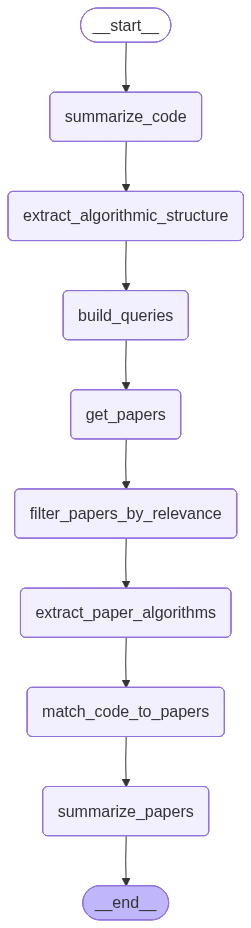

In [17]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("summarize_code", summarize_code)
graph_builder.add_node("extract_algorithmic_structure", extract_algorithmic_structure)
graph_builder.add_node("build_queries", build_queries)
graph_builder.add_node("get_papers", get_papers)
graph_builder.add_node("filter_papers_by_relevance", filter_papers_by_relevance)
graph_builder.add_node("extract_paper_algorithms", extract_paper_algorithms)
graph_builder.add_node("match_code_to_papers", match_code_to_papers)
graph_builder.add_node("summarize_papers", summarize_papers)

graph_builder.add_edge(START, "summarize_code")
graph_builder.add_edge("summarize_code", "extract_algorithmic_structure")
graph_builder.add_edge("extract_algorithmic_structure", "build_queries")
graph_builder.add_edge("build_queries", "get_papers")
graph_builder.add_edge("get_papers", "filter_papers_by_relevance")
graph_builder.add_edge("filter_papers_by_relevance", "extract_paper_algorithms")
graph_builder.add_edge("extract_paper_algorithms", "match_code_to_papers")
graph_builder.add_edge("match_code_to_papers", "summarize_papers")
graph_builder.add_edge("summarize_papers", END)

graph = graph_builder.compile()
graph

## Тесты агента

### Mock-пример
Передаётся кусок кода, построенный на основании  [Improving Adversarial Transferability via Neuron Attribution-Based Attacks](https://arxiv.org/pdf/2204.00008) и [How important is a neuron?](https://arxiv.org/pdf/1805.12233).

Если он их нашел, агент отработал успешно, если нет, то нет.

В текущем виде он не справляется, проблема, как сказано выше, в подготовке query и API arXiv.

In [18]:
example_code = '''
def compute_conductance(
    model,
    hook,
    x,
    x0,
    target_class,
    n_steps=64,
    fd_eps=1e-3,
    clear_every=8,
):
    """Estimate layer/neuron conductance along the baseline path using midpoint integration."""
    x = x.contiguous()
    x0 = x0.contiguous()
    delta_x = (x - x0).contiguous()

    def forward_with_layer(x_in):
        """Run a forward pass and return both model output and hooked layer activation."""
        hook.clear()
        out = model(x_in)
        act = unwrap_tensor(hook.get())
        return out, act

    alphas = torch.linspace(0.0, 1.0, n_steps + 1, device=x.device, dtype=x.dtype)
    step = 1.0 / n_steps

    cond_accum = None
    used_fallback = False

    for k in range(n_steps):
        alpha = (alphas[k] + alphas[k + 1]) / 2.0
        x_alpha = (x0 + alpha * delta_x).contiguous().detach().requires_grad_(True)

        out, act = forward_with_layer(x_alpha)
        _, logits = split_classifier_output(out)
        score = logits[0, target_class]

        # ∂F/∂y
        grad_y = torch.autograd.grad(score, act, retain_graph=False, create_graph=False)[0]

        try:
            def act_only(inp):
                """Return only layer activations for Jacobian-vector product computation."""
                inp = inp.contiguous()
                _, a = forward_with_layer(inp)
                return a

            # dy/dα
            _, act_tangent = jvp(act_only, (x_alpha,), (delta_x,))

        except RuntimeError as e:
            if "view size is not compatible with input tensor's size and stride" not in str(e):
                raise

            used_fallback = True

            alpha_plus = min(float(alpha.item()) + fd_eps, 1.0)
            alpha_minus = max(float(alpha.item()) - fd_eps, 0.0)
            denom = alpha_plus - alpha_minus

            if denom == 0.0:
                raise RuntimeError("Не удалось построить finite-difference fallback для dy/dalpha.")

            with torch.no_grad():
                _, act_plus = forward_with_layer((x0 + alpha_plus * delta_x).contiguous())
                _, act_minus = forward_with_layer((x0 + alpha_minus * delta_x).contiguous())

            # dy/dα ≈ [y(α+ε) - y(α-ε)] / (2ε)
            act_tangent = (act_plus - act_minus) / denom
            del act_plus, act_minus

        integrand = grad_y * act_tangent
        cond_accum = integrand.detach() if cond_accum is None else (cond_accum + integrand.detach())

        del x_alpha, out, act, logits, score, grad_y, act_tangent, integrand
        hook.clear()

        if (k + 1) % clear_every == 0:
            clear_backend_cache()

    cond = cond_accum * step
    clear_backend_cache()

    if used_fallback:
        print("Предупреждение: jvp на текущем backend не сработал, для dy/dalpha использована конечная разность.")

    return cond.detach()
'''

result = graph.invoke({"code": example_code})
print(result["final_summary"])

/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_48342/3476568256.py:18: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  for result in search.results():
/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_48342/3470385213.py:142: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().isoformat(timespec="seconds") + "Z"
/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_48342/3470385213.py:142: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow().isoformat(timespec="seconds") + "Z"
/var/folders/7c/tj2klhqj0xj4m6bh_9hd8_g00000gn/T/ipykernel_48342/3470385213.py:142: Deprecati

**Главный вывод:** Процесс, описанный в коде, **не рассматривается в найденных статьях почти один в один**. Алгоритм представляет собой гибридную методику, сочетающую идеи integrated gradients, neuron conductance и path integration с использованием Jacobian-vector product (JVP) для оценки вклада промежуточных активаций. Ни одна из статей не описывает такую точную комбинацию шагов, методов и технических деталей (hook на слой, вычисление `∂F/∂y` по активации, `dy/dα` через JVP/конечную разность, накопление `grad_y * act_tangent`). Таким образом, в коде присутствуют элементы, которые можно считать научно новыми или, как минимум, неочевидно покрытыми существующей литературой.

---

### 1. Статьи, где это уже есть почти один в один
**Нет таких статей.**  
Ни одна из проанализированных работ не описывает алгоритм, который бы совпадал с алгоритмической сигнатурой кода:
- Интегрирование вдоль непрерывного пути от `x0` к `x` с разбиением на шаги и взятием середины (`x_alpha`).
- Извлечение акти

In [19]:
from IPython.display import display, Markdown

display(Markdown((result["final_summary"])))

**Главный вывод:** Процесс, описанный в коде, **не рассматривается в найденных статьях почти один в один**. Алгоритм представляет собой гибридную методику, сочетающую идеи integrated gradients, neuron conductance и path integration с использованием Jacobian-vector product (JVP) для оценки вклада промежуточных активаций. Ни одна из статей не описывает такую точную комбинацию шагов, методов и технических деталей (hook на слой, вычисление `∂F/∂y` по активации, `dy/dα` через JVP/конечную разность, накопление `grad_y * act_tangent`). Таким образом, в коде присутствуют элементы, которые можно считать научно новыми или, как минимум, неочевидно покрытыми существующей литературой.

---

### 1. Статьи, где это уже есть почти один в один
**Нет таких статей.**  
Ни одна из проанализированных работ не описывает алгоритм, который бы совпадал с алгоритмической сигнатурой кода:
- Интегрирование вдоль непрерывного пути от `x0` к `x` с разбиением на шаги и взятием середины (`x_alpha`).
- Извлечение активаций **конкретного промежуточного слоя/нейрона** через hook.
- Вычисление градиента **целевого скора класса по этим активациям** (`∂F/∂y`).
- Вычисление **производной активации по параметру пути `alpha`** (`dy/dα`) с помощью **Jacobian-vector product (JVP)** или fallback на конечную разность.
- Накопление поэлементного произведения `grad_y * act_tangent` и умножение на шаг интегрирования.

Даже статья **SPINRec** (Fidelity-Aware Recommendation Explanations via Stochastic Path Integration), которая ближе всего по теме (path integration для объяснений), использует **совершенно другую механику**: усреднение объяснительных карт по множеству базовых линий (stochastic baseline sampling), а не численное интегрирование вдоль одного пути с градиентами по промежуточным активациям и JVP.

---

### 2. Частично релевантные статьи
Эти статьи затрагивают **общую идею "интегрирования по пути" (path integration)** в контексте интерпретации или обучения представлений, но **не покрывают ключевые шаги и методы кода**.

| Статья | Ссылка | Что совпадает | Что не совпадает / отсутствует |
|--------|--------|---------------|--------------------------------|
| **Fidelity-Aware Recommendation Explanations via Stochastic Path Integration (SPINRec)** | [arXiv:2511.18047](http://arxiv.org/abs/2511.18047v1) | Использование path integration для агрегации вкладов признаков вдоль траектории от базовой точки к целевой. | Нет вычисления градиентов по промежуточным активациям слоя (`∂F/∂y`), нет JVP для `dy/dα`, нет хуков на слой, нет накопления `grad_y * act_tangent`. Вместо этого — усреднение по множеству базовых линий. |
| **CrossEAI: Using Explainable AI to generate better bounding boxes for Chest X-ray images** | [arXiv:2310.19835](http://arxiv.org/abs/2310.19835v1) | Использование градиентных методов (Guided Backpropagation, Grad-CAM++) для объяснений. | Нет path integration вдоль пути между baseline и входом, нет JVP, нет численного интегрирования, нет оценки вклада активаций конкретного слоя/нейрона. |
| **Plan2Vec: Unsupervised Representation Learning by Latent Plans** | [arXiv:2005.03648](http://arxiv.org/abs/2005.03648v1) | Концепция "интеграции по пути" для согласования глобального расстояния с локальными переходами. | Алгоритм работает с **дискретным графом состояний** и поиском кратчайших путей, а не с непрерывным интегрированием вдоль пути между входами. Нет градиентов, JVP, хуков, оценки активаций слоёв. |
| **Multi-Scale Representation Learning for Spatial Feature Distributions using Grid Cells (Space2Vec)** | [arXiv:2003.00824](http://arxiv.org/abs/2003.00824v1) | Вдохновение grid cells и path integration для обучения пространственных представлений. | Алгоритм — это encoder-decoder модель с мульти-масштабным кодированием координат и attention, а не численное дифференцирование вдоль пути входа. Нет оценки вклада активаций, JVP, интегрирования от baseline. |

---

### 3. Фоновые, но полезные статьи
Эти работы **не покрывают алгоритм кода**, но дают контекст по смежным темам (path integration в нейробиологии/навигации, transfer learning, оценка переносимости знаний по слоям).

| Статья | Ссылка | Почему фоновая / полезная |
|--------|--------|---------------------------|
| **Boosting Brain-inspired Path Integration Efficiency via Learning-based Replication of Continuous Attractor Neurodynamics** | [arXiv:2511.17687](http://arxiv.org/abs/2511.17687v1) | Path integration в контексте навигации (замена CANN на LSTM). Полезна для понимания, как path integration реализуется в нейробиологически вдохновлённых системах, но **не имеет отношения к интерпретации моделей, градиентам по активациям или JVP**. |
| **Adaptive Path-Integral Autoencoder: Representation Learning and Planning for Dynamical Systems** | [arXiv:1807.02128](http://arxiv.org/abs/1807.02128v4) | Path Integral Adaptation для обучения представлений и планирования в динамических системах. Алгоритм использует симуляцию траекторий и importance sampling, но **не численное интегрирование вдоль пути между baseline и целевым входом** и не анализ активаций слоёв. |
| **A minimalistic representation model for head direction system** | [arXiv:2411.10596](http://arxiv.org/abs/2411.10596v2) | Обучение минималистичных представлений для системы направления головы с проекционным градиентным спуском. Полезна для понимания constrained learning в нейробиологических моделях, но **алгоритм не связан с path integration по входам модели или атрибуцией**. |
| **How Much Off-The-Shelf Knowledge Is Transferable From Natural Images To Pathology Images?** | [arXiv:2005.01609](http://arxiv.org/abs/2005.01609v3) | Оценка переносимости знаний по слоям CNN (knowledge gain). Полево для понимания, как разные слои вносят вклад в производительность, но **метод — это feature extraction + SVM, без path integration, JVP или интегрирования от baseline**. |
| **On Path Integration of Grid Cells: Group Representation and Isotropic Scaling** | [arXiv:2006.10259](http://arxiv.org/abs/2006.10259v6) | Теоретический анализ path integration в grid cells с точки зрения group representation. **Чисто теоретическая работа, без алгоритма для интерпретации нейросетей**. |
| **Agglomerative clustering and collectiveness measure via exponent generating function** | [arXiv:1507.08571](http://arxiv.org/abs/1507.08571v2) | Использует "path integral descriptor" как меру коллективности в графовой кластеризации. **Полностью другая область (кластеризация) и другая математика (экспоненциальная генерирующая функция на графах)**. |

---

### 4. Что в коде выглядит потенциально новым или неочевидно покрытым
Ключевые **новые/неочевидные элементы** по сравнению со всеми найденными статьями:

1. **Гибрид neuron conductance с path integration и JVP:**  
   Код оценивает вклад **промежуточных активаций конкретного слоя/нейрона** (concept "layer/neuron conductance") через **численное интегрирование вдоль пути** от baseline к входу, но вместо стандартного integrated gradients (который использует `∂F/∂x`) использует **`∂F/∂y` (градиент скора класса по активации слоя)**, умноженное на **`dy/dα` (производную активации по параметру пути)**, вычисленную через **Jacobian-vector product (JVP)** или конечную разность. Это сочетание:
   - **Neuron conductance** (оценка вклада нейрона через градиент по его активации) +
   - **Path integration** (интегрирование вдоль пути между baseline и входом) +
   - **JVP** (эффективное вычисление `dy/dα` без полного Jacobian) —
   не встречается в явном виде ни в одной из статей.

2. **Техническая реализация с hook и fallback:**  
   - Использование **hook** для извлечения активаций **промежуточного слоя** в процессе интегрирования.
   - **Fallback на конечную разность** при ошибке JVP (что важно для дифференцируемости и стабильности).
   - **Очистка кэша бэкенда** (`clear_backend_cache`) и хуков после каждого шага — инженерные детали, обеспечивающие корректность вычислений в PyTorch/functorch, но концептуально это часть реализации гибридного метода.

3. **Цель: оценка вклада активаций слоя в изменение предсказания**  
   В статьях path integration используется либо для:
   - **Обучения представлений** (Plan2Vec, Space2Vec, Adaptive Path-Integral Autoencoder),
   - **Навигации/планирования** (Boosting Brain-inspired PI, On Path Integration of Grid Cells),
   - **Генерации объяснений через усреднение по baseline** (SPINRec),
   - **Кластеризации** (Agglomerative clustering).
   Ни одна работа не ставит задачу **"какова вклад промежуточных активаций слоя (нейрона) в изменение предсказания модели при переходе от baseline к входу?"** и не решает её описанным способом.

**Вывод:** Алгоритм кода — это **специализированный метод интерпретируемости** (атрибуция на уровне слоёв/нейронов), который **интегрирует несколько идей** (conductance, path integration, JVP) в новую комбинацию. Он не дублирует ни один из найденных алгоритмов, хотя использует общие концепции (path integration, baseline, градиенты). Поэтому можно утверждать, что в коде присутствует **научная новизна** в рамках задачи оценки вклада промежуточных активаций.